# Práctica II — Visión por Computador

Notebook secuencial alineado con el enunciado: **preprocesamiento → segmentación → morfología → bordes → esquinas → descriptores → clasificación → experimentos → resultados**.


In [1]:
# ============================================================
# 1. CONFIGURACIÓN E IMPORTS
# ============================================================
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

from skimage import filters, morphology, exposure, feature
from skimage.feature import local_binary_pattern, hog

from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_DIR = "/home/bianca/Documents/vision/practica2/PlantVillage"
IMG_SIZE = (128, 128)
N_SPLITS = 5
MAX_PER_CLASS = 300

In [2]:
# ============================================================
# 2. FUNCIONES AUXILIARES
# ============================================================
def read_image_rgb(path, resize=None):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if resize is not None:
        img = cv2.resize(img, resize)
    return img


def show_images(images, titles=None, cols=4, figsize=(14, 8), cmap=None):
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else "gray")
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(str(titles[i]))
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def overlay_points(image_rgb, points, color=(255, 0, 0), radius=2):
    img = image_rgb.copy()
    for y, x in points:
        cv2.circle(img, (int(x), int(y)), radius, color, -1)
    return img

In [ ]:
# ============================================================
# 3. CARGA DEL DATASET
# ============================================================
def build_dataframe_from_folder(dataset_dir):
    rows = []
    class_dirs = sorted(
        [
            d
            for d in os.listdir(dataset_dir)
            if os.path.isdir(os.path.join(dataset_dir, d))
        ]
    )
    valid_ext = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    for class_name in class_dirs:
        class_path = os.path.join(dataset_dir, class_name)
        for fname in os.listdir(class_path):
            ext = os.path.splitext(fname)[1]
            if ext in valid_ext:
                rows.append(
                    {"path": os.path.join(class_path, fname), "label": class_name}
                )
    return pd.DataFrame(rows)


df_images = build_dataframe_from_folder(DATASET_DIR)
print("Cantidad total de imágenes:", len(df_images))
print("Cantidad de clases:", df_images["label"].nunique())
display(df_images.head())
display(df_images["label"].value_counts().sort_index())

Cantidad total de imágenes: 20638
Cantidad de clases: 15


,path,label
0,/home/bianca/Documents/vision/practica2/PlantV...,Pepper__bell___Bacterial_spot
1,/home/bianca/Documents/vision/practica2/PlantV...,Pepper__bell___Bacterial_spot
2,/home/bianca/Documents/vision/practica2/PlantV...,Pepper__bell___Bacterial_spot
3,/home/bianca/Documents/vision/practica2/PlantV...,Pepper__bell___Bacterial_spot
4,/home/bianca/Documents/vision/practica2/PlantV...,Pepper__bell___Bacterial_spot


label
Pepper__bell___Bacterial_spot                   997
Pepper__bell___healthy                         1478
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Potato___healthy                                152
Tomato_Bacterial_spot                          2127
Tomato_Early_blight                            1000
Tomato_Late_blight                             1909
Tomato_Leaf_Mold                                952
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato__Target_Spot                            1404
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato__Tomato_mosaic_virus                     373
Tomato_healthy                                 1591
Name: count, dtype: int64

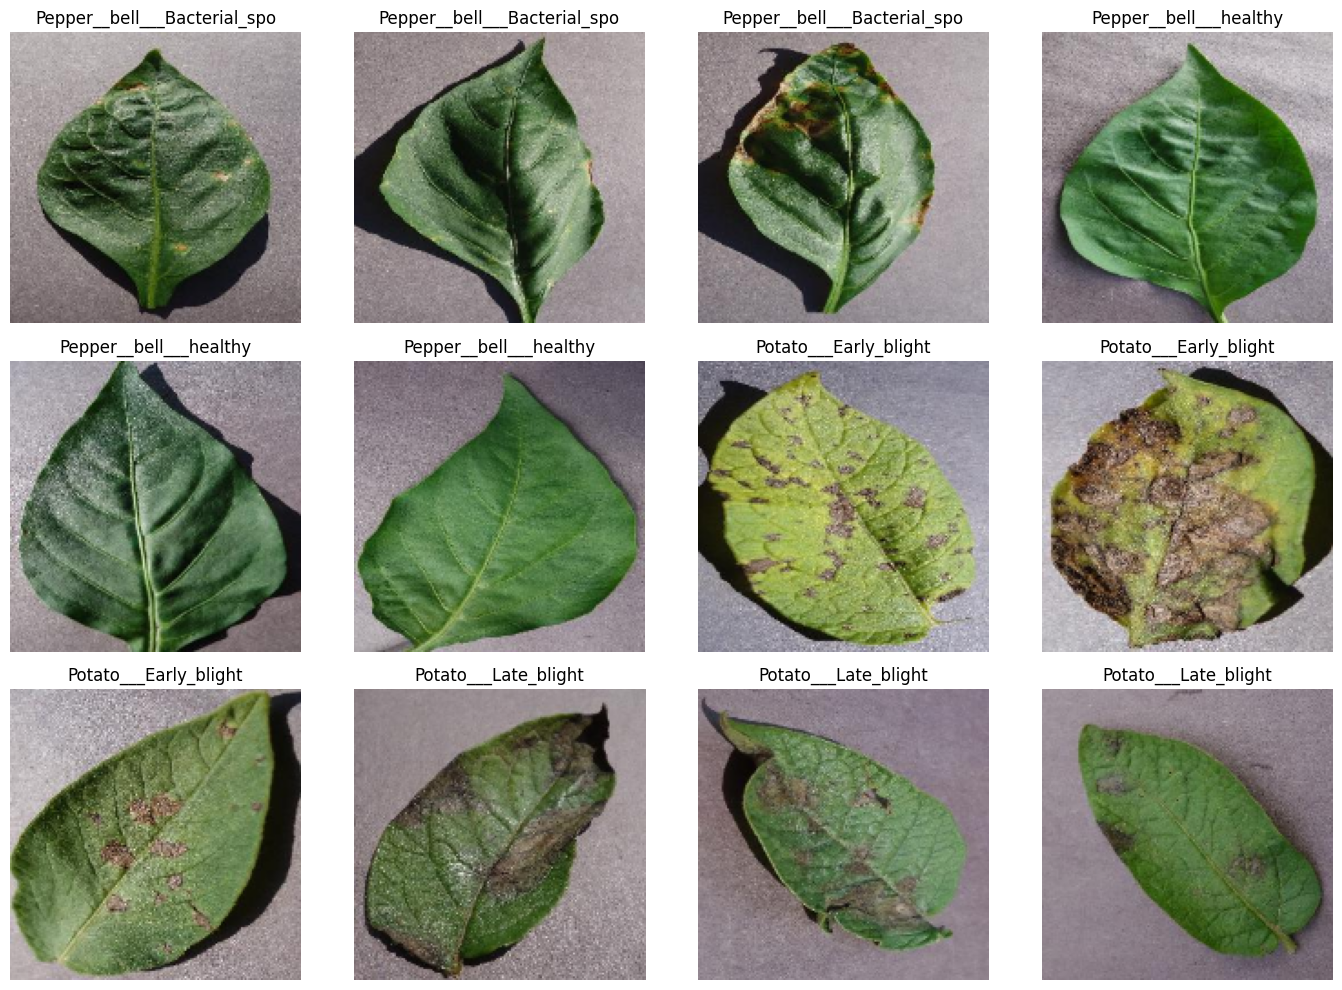

In [ ]:
# ============================================================
# 4. MUESTRA RÁPIDA DEL DATASET
# ============================================================
sample_parts = []
for label_name, group in df_images.groupby("label"):
    n_take = min(3, len(group))
    sample_parts.append(group.sample(n=n_take, random_state=RANDOM_STATE))
sample_df = pd.concat(sample_parts, axis=0).reset_index(drop=True)

imgs = [read_image_rgb(p, resize=(160, 160)) for p in sample_df["path"][:12]]
titles = [str(lbl)[:28] for lbl in sample_df["label"][:12]]
show_images(imgs, titles=titles, cols=4, figsize=(14, 10))

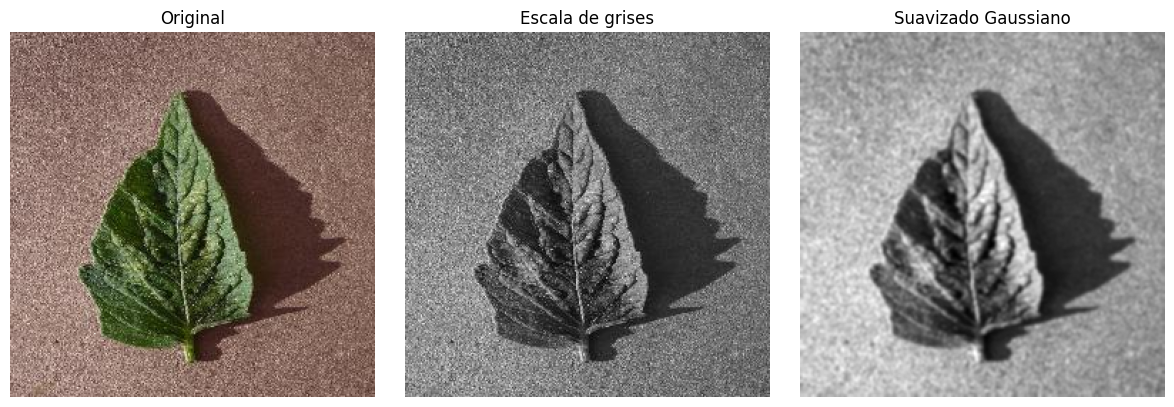

In [ ]:
# ============================================================
# 5. PREPROCESAMIENTO
# ============================================================
def preprocess_image(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    return gray, blur


example_path = df_images.sample(1, random_state=RANDOM_STATE)["path"].iloc[0]
example_img = read_image_rgb(example_path, resize=(256, 256))
gray_img, blur_img = preprocess_image(example_img)

show_images(
    [example_img, gray_img, blur_img],
    titles=["Original", "Escala de grises", "Suavizado Gaussiano"],
    cols=3,
    figsize=(12, 4),
)

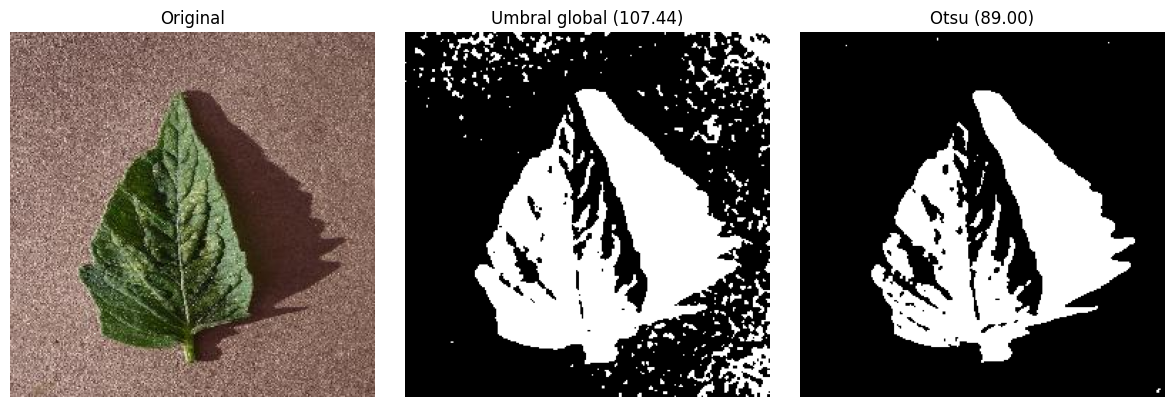

In [ ]:
# ============================================================
# 6. SEGMENTACIÓN
# ============================================================
def segment_leaf(gray_or_blur):
    global_thresh = gray_or_blur.mean()
    mask_global = (gray_or_blur < global_thresh).astype(np.uint8)
    otsu_thresh = filters.threshold_otsu(gray_or_blur)
    mask_otsu = (gray_or_blur < otsu_thresh).astype(np.uint8)
    return mask_global, mask_otsu, global_thresh, otsu_thresh


mask_global, mask_otsu, g_thr, o_thr = segment_leaf(blur_img)
show_images(
    [example_img, mask_global * 255, mask_otsu * 255],
    titles=[f"Original", f"Umbral global ({g_thr:.2f})", f"Otsu ({o_thr:.2f})"],
    cols=3,
    figsize=(12, 4),
)

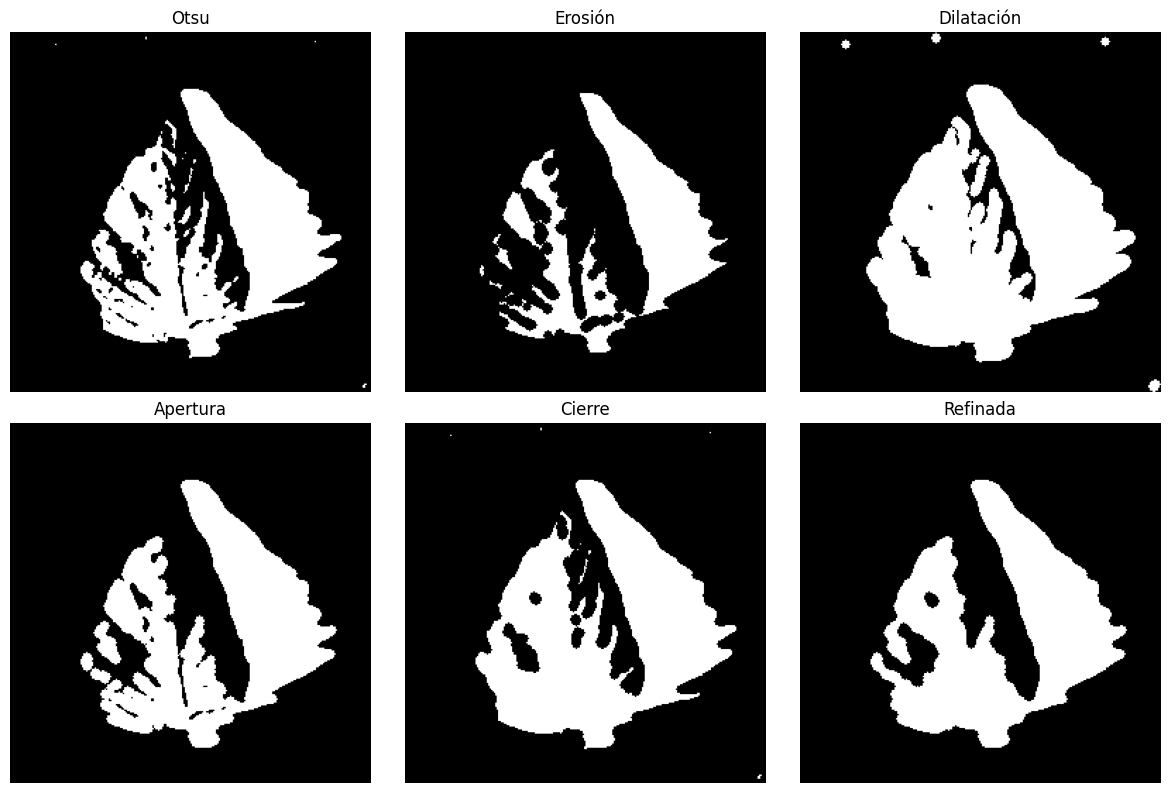

In [ ]:
# ============================================================
# 7. OPERACIONES MORFOLÓGICAS
# ============================================================
def refine_mask(mask):
    selem = morphology.disk(3)
    eroded = morphology.erosion(mask, selem)
    dilated = morphology.dilation(mask, selem)
    opened = morphology.opening(mask, selem)
    closed = morphology.closing(mask, selem)
    refined = morphology.closing(opened, selem)
    return eroded, dilated, opened, closed, refined


eroded, dilated, opened, closed, refined = refine_mask(mask_otsu)
show_images(
    [
        mask_otsu * 255,
        eroded * 255,
        dilated * 255,
        opened * 255,
        closed * 255,
        refined * 255,
    ],
    titles=["Otsu", "Erosión", "Dilatación", "Apertura", "Cierre", "Refinada"],
    cols=3,
    figsize=(12, 8),
)

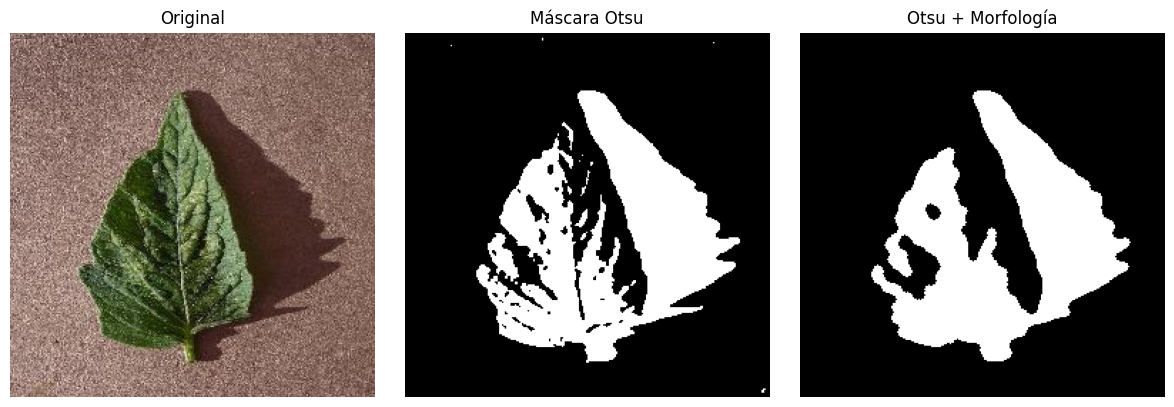

In [ ]:
# ============================================================
# 8. COMPARACIÓN DE SEGMENTACIÓN ANTES / DESPUÉS
# ============================================================
show_images(
    [example_img, mask_otsu * 255, refined * 255],
    titles=["Original", "Máscara Otsu", "Otsu + Morfología"],
    cols=3,
    figsize=(12, 4),
)

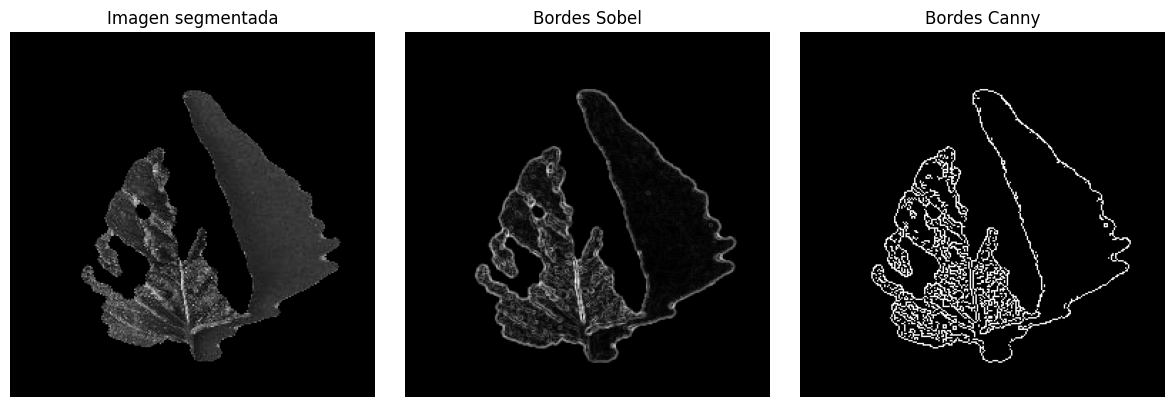

In [ ]:
# ============================================================
# 9. DETECCIÓN DE BORDES
# ============================================================
def edges_from_segmented(gray_img, mask_refined):
    masked_gray = gray_img.copy()
    masked_gray[mask_refined == 0] = 0
    sobel = filters.sobel(masked_gray)
    sobel_vis = (sobel / (sobel.max() + 1e-8) * 255).astype(np.uint8)
    canny = cv2.Canny(masked_gray, 80, 160)
    return masked_gray, sobel_vis, canny


masked_gray, sobel_edges, canny_edges = edges_from_segmented(gray_img, refined)
show_images(
    [masked_gray, sobel_edges, canny_edges],
    titles=["Imagen segmentada", "Bordes Sobel", "Bordes Canny"],
    cols=3,
    figsize=(12, 4),
)

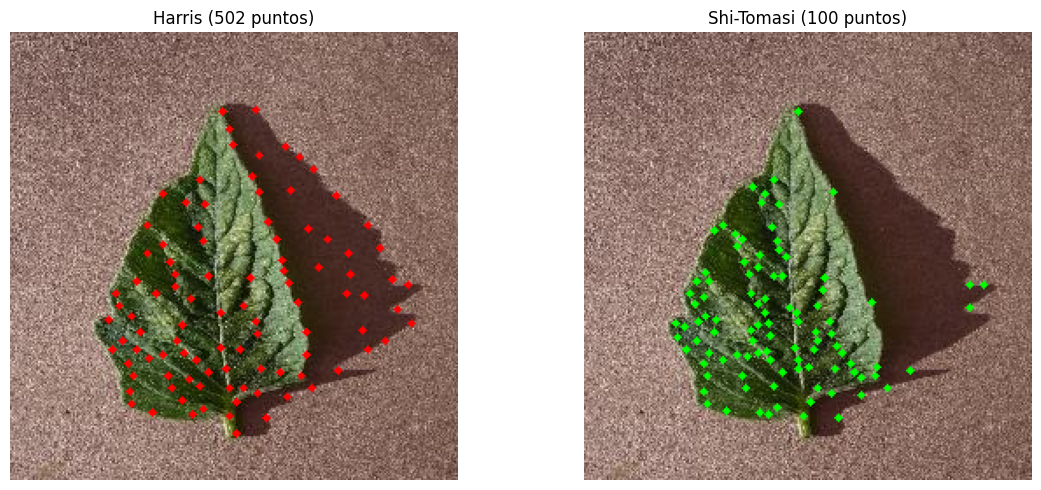

In [ ]:
# ============================================================
# 10. DETECCIÓN DE ESQUINAS
# ============================================================
def detect_harris_corners(gray_img, mask_refined, min_distance=5):
    masked_gray = gray_img.copy()
    masked_gray[mask_refined == 0] = 0
    harris_response = feature.corner_harris(masked_gray)
    corners = feature.corner_peaks(harris_response, min_distance=min_distance)
    return corners


def detect_shi_tomasi(gray_img, mask_refined, max_corners=100):
    masked_gray = gray_img.copy()
    masked_gray[mask_refined == 0] = 0
    corners = cv2.goodFeaturesToTrack(
        masked_gray, maxCorners=max_corners, qualityLevel=0.01, minDistance=5
    )
    if corners is None:
        return np.empty((0, 2), dtype=int)
    corners = corners.squeeze(axis=1)
    return np.array([[int(c[1]), int(c[0])] for c in corners])


harris_pts = detect_harris_corners(gray_img, refined)
shi_pts = detect_shi_tomasi(gray_img, refined)
img_harris = overlay_points(example_img, harris_pts[:100], color=(255, 0, 0), radius=2)
img_shi = overlay_points(example_img, shi_pts[:100], color=(0, 255, 0), radius=2)
show_images(
    [img_harris, img_shi],
    titles=[
        f"Harris ({len(harris_pts)} puntos)",
        f"Shi-Tomasi ({len(shi_pts)} puntos)",
    ],
    cols=2,
    figsize=(12, 5),
)

In [ ]:
# ============================================================
# 11. FUNCIONES DE DESCRIPTORES
# ============================================================
def apply_mask_rgb(image_rgb, mask):
    out = image_rgb.copy()
    out[mask == 0] = 0
    return out


def resize_for_features(image_rgb, mask, size=IMG_SIZE):
    img_res = cv2.resize(image_rgb, size)
    mask_res = cv2.resize(mask.astype(np.uint8), size, interpolation=cv2.INTER_NEAREST)
    return img_res, mask_res


def pipeline_segmentation_from_rgb(image_rgb):
    gray, blur = preprocess_image(image_rgb)
    _, mask_otsu, _, _ = segment_leaf(blur)
    _, _, _, _, refined = refine_mask(mask_otsu)
    return gray, blur, refined

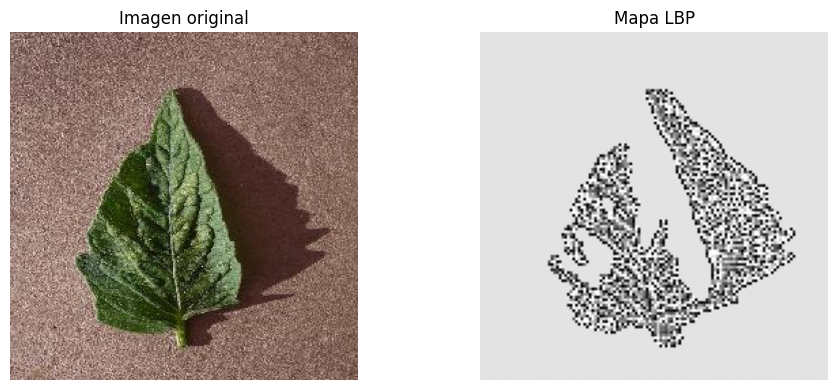

Dimensión vector LBP: 10


In [ ]:
# ============================================================
# 12. LBP
# ============================================================
def extract_lbp_features(image_rgb, mask, P=8, R=1):
    img_res, mask_res = resize_for_features(image_rgb, mask)
    gray = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)
    gray[mask_res == 0] = 0
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    n_bins = P + 2
    hist, _ = np.histogram(
        lbp[mask_res > 0], bins=n_bins, range=(0, n_bins), density=True
    )
    lbp_vis = (lbp / (lbp.max() + 1e-8) * 255).astype(np.uint8)
    return hist, lbp_vis


lbp_vec, lbp_vis = extract_lbp_features(example_img, refined)
show_images(
    [example_img, lbp_vis],
    titles=["Imagen original", "Mapa LBP"],
    cols=2,
    figsize=(10, 4),
)
print("Dimensión vector LBP:", len(lbp_vec))

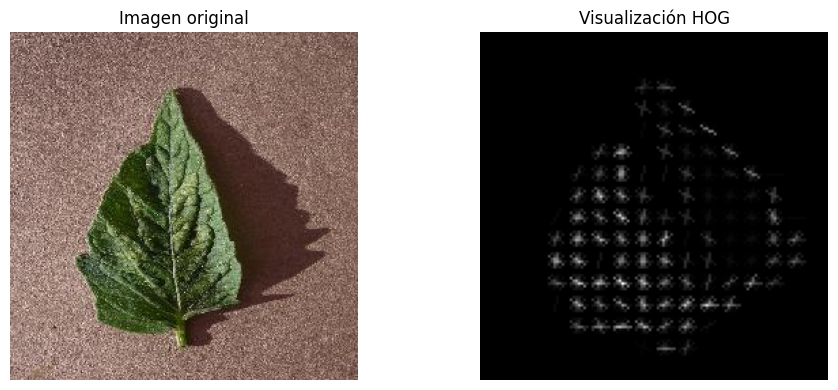

Dimensión vector HOG: 8100


In [ ]:
# ============================================================
# 13. HOG
# ============================================================
def extract_hog_features(image_rgb, mask):
    img_res, mask_res = resize_for_features(image_rgb, mask)
    gray = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)
    gray[mask_res == 0] = 0
    hog_vec, hog_img = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
    )
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() + 1e-8))
    hog_img = (hog_img * 255).astype(np.uint8)
    return hog_vec, hog_img


hog_vec, hog_vis = extract_hog_features(example_img, refined)
show_images(
    [example_img, hog_vis],
    titles=["Imagen original", "Visualización HOG"],
    cols=2,
    figsize=(10, 4),
)
print("Dimensión vector HOG:", len(hog_vec))

In [ ]:
# ============================================================
# 14. BAG OF WORDS
# ============================================================
def extract_orb_descriptors(image_rgb, mask, nfeatures=300):
    img_res, mask_res = resize_for_features(image_rgb, mask)
    gray = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)
    orb = cv2.ORB_create(nfeatures=nfeatures)
    keypoints, descriptors = orb.detectAndCompute(gray, mask_res.astype(np.uint8))
    return keypoints, descriptors

In [ ]:
# ============================================================
# 15. DESCRIPTOR PROPIO (COLOR + ÁREA LESIONADA)
# ============================================================
def extract_custom_features(image_rgb, mask):
    img_res, mask_res = resize_for_features(image_rgb, mask)
    masked = apply_mask_rgb(img_res, mask_res)
    hsv = cv2.cvtColor(masked, cv2.COLOR_RGB2HSV)
    rgb = masked.copy()
    valid = mask_res > 0
    if valid.sum() == 0:
        return np.zeros(14, dtype=np.float32)
    feats = []
    for c in range(3):
        vals = rgb[..., c][valid]
        feats.extend([vals.mean(), vals.std()])
    for c in range(3):
        vals = hsv[..., c][valid]
        feats.extend([vals.mean(), vals.std()])
    feats.append(valid.mean())
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]
    lesion_mask = ((h < 25) | (h > 150)) & (s > 40) & (v < 180) & valid
    feats.append(lesion_mask.sum() / (valid.sum() + 1e-8))
    return np.array(feats, dtype=np.float32)


custom_vec = extract_custom_features(example_img, refined)
print("Dimensión descriptor propio:", len(custom_vec))
print(custom_vec)

Dimensión descriptor propio: 14
[ 61.70181     20.22729     55.318954    23.212864    33.26065
  18.661877    24.199148    18.152288   138.36555     36.462914
  68.213524    19.970818     0.22924805   0.506656  ]


In [ ]:
# ============================================================
# 16. EXTRACCIÓN DE FEATURES PARA TODO EL DATASET
# ============================================================
balanced_parts = []
for cls, group in df_images.groupby("label"):
    n_take = min(MAX_PER_CLASS, len(group))
    balanced_parts.append(group.sample(n=n_take, random_state=RANDOM_STATE))
df_work = pd.concat(balanced_parts).reset_index(drop=True)
print("Dataset de trabajo:", len(df_work))
print(df_work["label"].value_counts().sort_index())

Dataset de trabajo: 4352
label
Pepper__bell___Bacterial_spot                  300
Pepper__bell___healthy                         300
Potato___Early_blight                          300
Potato___Late_blight                           300
Potato___healthy                               152
Tomato_Bacterial_spot                          300
Tomato_Early_blight                            300
Tomato_Late_blight                             300
Tomato_Leaf_Mold                               300
Tomato_Septoria_leaf_spot                      300
Tomato_Spider_mites_Two_spotted_spider_mite    300
Tomato__Target_Spot                            300
Tomato__Tomato_YellowLeaf__Curl_Virus          300
Tomato__Tomato_mosaic_virus                    300
Tomato_healthy                                 300
Name: count, dtype: int64


In [ ]:
lbp_features, hog_features, custom_features = [], [], []
labels, paths, masks_cache = [], [], {}

for _, row in tqdm(df_work.iterrows(), total=len(df_work)):
    path = row["path"]
    label_name = row["label"]
    image_rgb = read_image_rgb(path, resize=(256, 256))
    _, _, mask = pipeline_segmentation_from_rgb(image_rgb)
    lbp_vec, _ = extract_lbp_features(image_rgb, mask)
    hog_vec, _ = extract_hog_features(image_rgb, mask)
    custom_vec = extract_custom_features(image_rgb, mask)
    lbp_features.append(lbp_vec)
    hog_features.append(hog_vec)
    custom_features.append(custom_vec)
    labels.append(label_name)
    paths.append(path)
    masks_cache[path] = mask

X_lbp = np.array(lbp_features, dtype=np.float32)
X_hog = np.array(hog_features, dtype=np.float32)
X_custom = np.array(custom_features, dtype=np.float32)
y_labels = np.array(labels)
print("LBP:", X_lbp.shape)
print("HOG:", X_hog.shape)
print("CUSTOM:", X_custom.shape)

100%|██████████| 4352/4352 [08:58<00:00,  8.09it/s]


LBP: (4352, 10)
HOG: (4352, 8100)
CUSTOM: (4352, 14)


In [ ]:
# ============================================================
# 17. PREPARACIÓN DE DESCRIPTORES ORB PARA BOW
# ============================================================
orb_desc_list = []
for path in tqdm(paths):
    image_rgb = read_image_rgb(path, resize=(256, 256))
    mask = masks_cache[path]
    _, desc = extract_orb_descriptors(image_rgb, mask)
    orb_desc_list.append(desc)
print("Listo: descriptores ORB extraídos")

100%|██████████| 4352/4352 [00:12<00:00, 348.85it/s]

Listo: descriptores ORB extraídos


In [ ]:
# ============================================================
# 18. UTILIDADES DE EVALUACIÓN
# ============================================================
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)


def build_bow_features_for_fold(orb_desc_list, train_idx, test_idx, n_clusters=64):
    train_descs = []
    for idx in train_idx:
        desc = orb_desc_list[idx]
        if desc is not None and len(desc) > 0:
            train_descs.append(desc.astype(np.float32))
    if len(train_descs) == 0:
        raise ValueError("No hay descriptores ORB suficientes en train.")
    train_descs = np.vstack(train_descs)
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters, random_state=RANDOM_STATE, batch_size=1024
    )
    kmeans.fit(train_descs)

    def image_to_hist(desc):
        hist = np.zeros(n_clusters, dtype=np.float32)
        if desc is not None and len(desc) > 0:
            words = kmeans.predict(desc.astype(np.float32))
            for w in words:
                hist[w] += 1
            hist = hist / (hist.sum() + 1e-8)
        return hist

    X_train_bow = np.array(
        [image_to_hist(orb_desc_list[idx]) for idx in train_idx], dtype=np.float32
    )
    X_test_bow = np.array(
        [image_to_hist(orb_desc_list[idx]) for idx in test_idx], dtype=np.float32
    )
    return X_train_bow, X_test_bow


def evaluate_model_cv(X, y, model_name="svm", param_grid=None):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    all_true, all_pred, fold_acc, fold_f1 = [], [], [], []
    if param_grid is None:
        param_grid = [{}]
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        best_model, best_score = None, -1
        for params in ParameterGrid(param_grid):
            if model_name == "knn":
                model = KNeighborsClassifier(**params)
            elif model_name == "svm":
                model = SVC(**params)
            elif model_name == "rf":
                model = RandomForestClassifier(random_state=RANDOM_STATE, **params)
            else:
                raise ValueError("Modelo no soportado")
            model.fit(X_train, y_train)
            pred_val = model.predict(X_test)
            score = f1_score(y_test, pred_val, average="macro")
            if score > best_score:
                best_score, best_model = score, model
        y_pred = best_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        fold_acc.append(acc)
        fold_f1.append(f1m)
        all_true.extend(y_test)
        all_pred.extend(y_pred)
        print(f"Fold {fold}: Acc={acc:.4f} | Macro-F1={f1m:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    report = classification_report(
        all_true, all_pred, target_names=label_encoder.classes_, output_dict=True
    )
    return {
        "acc_mean": np.mean(fold_acc),
        "f1_mean": np.mean(fold_f1),
        "confusion_matrix": cm,
        "report": report,
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
    }


knn_grid = {"n_neighbors": [1, 3, 5, 7]}
svm_grid = {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale"]}
rf_grid = {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}

In [ ]:
# ============================================================
# 19. CLASIFICACIÓN CON LBP
# ============================================================
print("=== LBP + kNN ===")
res_lbp_knn = evaluate_model_cv(X_lbp, y, model_name="knn", param_grid=knn_grid)
print("=== LBP + SVM ===")
res_lbp_svm = evaluate_model_cv(X_lbp, y, model_name="svm", param_grid=svm_grid)
print("=== LBP + RF ===")
res_lbp_rf = evaluate_model_cv(X_lbp, y, model_name="rf", param_grid=rf_grid)

=== LBP + kNN ===
Fold 1: Acc=0.3111 | Macro-F1=0.3128
Fold 2: Acc=0.3065 | Macro-F1=0.2965
Fold 3: Acc=0.2839 | Macro-F1=0.2780
Fold 4: Acc=0.3046 | Macro-F1=0.3035
Fold 5: Acc=0.3172 | Macro-F1=0.3120
=== LBP + SVM ===
Fold 1: Acc=0.3708 | Macro-F1=0.3560
Fold 2: Acc=0.3548 | Macro-F1=0.3401
Fold 3: Acc=0.3816 | Macro-F1=0.3710
Fold 4: Acc=0.3793 | Macro-F1=0.3661
Fold 5: Acc=0.3690 | Macro-F1=0.3576
=== LBP + RF ===
Fold 1: Acc=0.3513 | Macro-F1=0.3460
Fold 2: Acc=0.3685 | Macro-F1=0.3531
Fold 3: Acc=0.3621 | Macro-F1=0.3499
Fold 4: Acc=0.3816 | Macro-F1=0.3761
Fold 5: Acc=0.3736 | Macro-F1=0.3611


In [ ]:
# ============================================================
# 20. CLASIFICACIÓN CON HOG
# ============================================================
print("=== HOG + kNN ===")
res_hog_knn = evaluate_model_cv(X_hog, y, model_name="knn", param_grid=knn_grid)
print("=== HOG + SVM ===")
res_hog_svm = evaluate_model_cv(X_hog, y, model_name="svm", param_grid=svm_grid)
print("=== HOG + RF ===")
res_hog_rf = evaluate_model_cv(X_hog, y, model_name="rf", param_grid=rf_grid)

=== HOG + kNN ===
Fold 1: Acc=0.4191 | Macro-F1=0.4002
Fold 2: Acc=0.4202 | Macro-F1=0.3968
Fold 3: Acc=0.4057 | Macro-F1=0.3897
Fold 4: Acc=0.4184 | Macro-F1=0.3971
Fold 5: Acc=0.4356 | Macro-F1=0.4175
=== HOG + SVM ===
Fold 1: Acc=0.5786 | Macro-F1=0.5692
Fold 2: Acc=0.5660 | Macro-F1=0.5500
Fold 3: Acc=0.5460 | Macro-F1=0.5352
Fold 4: Acc=0.5908 | Macro-F1=0.5809
Fold 5: Acc=0.5655 | Macro-F1=0.5519
=== HOG + RF ===
Fold 1: Acc=0.4455 | Macro-F1=0.4026
Fold 2: Acc=0.4489 | Macro-F1=0.4027
Fold 3: Acc=0.4184 | Macro-F1=0.3739
Fold 4: Acc=0.4425 | Macro-F1=0.4008
Fold 5: Acc=0.4264 | Macro-F1=0.3844


In [ ]:
# ============================================================
# 21. CLASIFICACIÓN CON DESCRIPTOR PROPIO
# ============================================================
print("=== CUSTOM + kNN ===")
res_custom_knn = evaluate_model_cv(X_custom, y, model_name="knn", param_grid=knn_grid)
print("=== CUSTOM + SVM ===")
res_custom_svm = evaluate_model_cv(X_custom, y, model_name="svm", param_grid=svm_grid)
print("=== CUSTOM + RF ===")
res_custom_rf = evaluate_model_cv(X_custom, y, model_name="rf", param_grid=rf_grid)

=== CUSTOM + kNN ===
Fold 1: Acc=0.6521 | Macro-F1=0.6467
Fold 2: Acc=0.6682 | Macro-F1=0.6577
Fold 3: Acc=0.6287 | Macro-F1=0.6219
Fold 4: Acc=0.6644 | Macro-F1=0.6559
Fold 5: Acc=0.6322 | Macro-F1=0.6244
=== CUSTOM + SVM ===
Fold 1: Acc=0.7669 | Macro-F1=0.7640
Fold 2: Acc=0.7623 | Macro-F1=0.7537
Fold 3: Acc=0.7609 | Macro-F1=0.7566
Fold 4: Acc=0.7678 | Macro-F1=0.7617
Fold 5: Acc=0.7713 | Macro-F1=0.7629
=== CUSTOM + RF ===
Fold 1: Acc=0.6751 | Macro-F1=0.6714
Fold 2: Acc=0.7084 | Macro-F1=0.7003
Fold 3: Acc=0.6759 | Macro-F1=0.6698
Fold 4: Acc=0.6874 | Macro-F1=0.6827
Fold 5: Acc=0.6931 | Macro-F1=0.6861


In [ ]:
# ============================================================
# 22. CLASIFICACIÓN CON BOW (sin fuga de información)
# ============================================================
def evaluate_bow_cv(orb_desc_list, y, model_name="svm", param_grid=None, n_clusters=64):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    all_true, all_pred, fold_acc, fold_f1 = [], [], [], []
    if param_grid is None:
        param_grid = [{}]
    for fold, (train_idx, test_idx) in enumerate(
        skf.split(np.arange(len(y)), y), start=1
    ):
        X_train_bow, X_test_bow = build_bow_features_for_fold(
            orb_desc_list, train_idx, test_idx, n_clusters=n_clusters
        )
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train_bow = scaler.fit_transform(X_train_bow)
        X_test_bow = scaler.transform(X_test_bow)
        best_model, best_score = None, -1
        for params in ParameterGrid(param_grid):
            if model_name == "knn":
                model = KNeighborsClassifier(**params)
            elif model_name == "svm":
                model = SVC(**params)
            elif model_name == "rf":
                model = RandomForestClassifier(random_state=RANDOM_STATE, **params)
            else:
                raise ValueError("Modelo no soportado")
            model.fit(X_train_bow, y_train)
            pred_val = model.predict(X_test_bow)
            score = f1_score(y_test, pred_val, average="macro")
            if score > best_score:
                best_score, best_model = score, model
        y_pred = best_model.predict(X_test_bow)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        fold_acc.append(acc)
        fold_f1.append(f1m)
        all_true.extend(y_test)
        all_pred.extend(y_pred)
        print(f"Fold {fold}: Acc={acc:.4f} | Macro-F1={f1m:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    report = classification_report(
        all_true, all_pred, target_names=label_encoder.classes_, output_dict=True
    )
    return {
        "acc_mean": np.mean(fold_acc),
        "f1_mean": np.mean(fold_f1),
        "confusion_matrix": cm,
        "report": report,
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
    }


print("=== BOW + kNN ===")
res_bow_knn = evaluate_bow_cv(orb_desc_list, y, model_name="knn", param_grid=knn_grid)
print("=== BOW + SVM ===")
res_bow_svm = evaluate_bow_cv(orb_desc_list, y, model_name="svm", param_grid=svm_grid)
print("=== BOW + RF ===")
res_bow_rf = evaluate_bow_cv(orb_desc_list, y, model_name="rf", param_grid=rf_grid)

=== BOW + kNN ===
Fold 1: Acc=0.1274 | Macro-F1=0.1245
Fold 2: Acc=0.1240 | Macro-F1=0.1158
Fold 3: Acc=0.1069 | Macro-F1=0.1020
Fold 4: Acc=0.1241 | Macro-F1=0.1153
Fold 5: Acc=0.1138 | Macro-F1=0.1053
=== BOW + SVM ===
Fold 1: Acc=0.2170 | Macro-F1=0.2122
Fold 2: Acc=0.2158 | Macro-F1=0.2070
Fold 3: Acc=0.2115 | Macro-F1=0.1990
Fold 4: Acc=0.2276 | Macro-F1=0.2125
Fold 5: Acc=0.2046 | Macro-F1=0.1934
=== BOW + RF ===
Fold 1: Acc=0.2009 | Macro-F1=0.1820
Fold 2: Acc=0.2055 | Macro-F1=0.1906
Fold 3: Acc=0.2023 | Macro-F1=0.1789
Fold 4: Acc=0.2195 | Macro-F1=0.2010
Fold 5: Acc=0.1920 | Macro-F1=0.1823


In [ ]:
# ============================================================
# 23. COMBINACIÓN DE DESCRIPTORES
# ============================================================
X_lbp_hog = np.concatenate([X_lbp, X_hog], axis=1)
X_hog_custom = np.concatenate([X_hog, X_custom], axis=1)
X_lbp_hog_custom = np.concatenate([X_lbp, X_hog, X_custom], axis=1)

print("=== LBP + HOG + SVM ===")
res_lbp_hog_svm = evaluate_model_cv(X_lbp_hog, y, model_name="svm", param_grid=svm_grid)
print("=== HOG + CUSTOM + SVM ===")
res_hog_custom_svm = evaluate_model_cv(
    X_hog_custom, y, model_name="svm", param_grid=svm_grid
)
print("=== LBP + HOG + CUSTOM + SVM ===")
res_lbp_hog_custom_svm = evaluate_model_cv(
    X_lbp_hog_custom, y, model_name="svm", param_grid=svm_grid
)

=== LBP + HOG + SVM ===
Fold 1: Acc=0.5890 | Macro-F1=0.5790
Fold 2: Acc=0.5706 | Macro-F1=0.5557
Fold 3: Acc=0.5586 | Macro-F1=0.5496
Fold 4: Acc=0.5966 | Macro-F1=0.5871
Fold 5: Acc=0.5770 | Macro-F1=0.5646
=== HOG + CUSTOM + SVM ===
Fold 1: Acc=0.5913 | Macro-F1=0.5821
Fold 2: Acc=0.5752 | Macro-F1=0.5595
Fold 3: Acc=0.5552 | Macro-F1=0.5457
Fold 4: Acc=0.5931 | Macro-F1=0.5834
Fold 5: Acc=0.5736 | Macro-F1=0.5610
=== LBP + HOG + CUSTOM + SVM ===
Fold 1: Acc=0.5924 | Macro-F1=0.5825
Fold 2: Acc=0.5752 | Macro-F1=0.5665
Fold 3: Acc=0.5667 | Macro-F1=0.5602
Fold 4: Acc=0.6057 | Macro-F1=0.5967
Fold 5: Acc=0.5828 | Macro-F1=0.5697


In [ ]:
# ============================================================
# 24. RESUMEN DE RESULTADOS
# ============================================================
summary_rows = [
    ["LBP + kNN", res_lbp_knn["acc_mean"], res_lbp_knn["f1_mean"]],
    ["LBP + SVM", res_lbp_svm["acc_mean"], res_lbp_svm["f1_mean"]],
    ["LBP + RF", res_lbp_rf["acc_mean"], res_lbp_rf["f1_mean"]],
    ["HOG + kNN", res_hog_knn["acc_mean"], res_hog_knn["f1_mean"]],
    ["HOG + SVM", res_hog_svm["acc_mean"], res_hog_svm["f1_mean"]],
    ["HOG + RF", res_hog_rf["acc_mean"], res_hog_rf["f1_mean"]],
    ["CUSTOM + kNN", res_custom_knn["acc_mean"], res_custom_knn["f1_mean"]],
    ["CUSTOM + SVM", res_custom_svm["acc_mean"], res_custom_svm["f1_mean"]],
    ["CUSTOM + RF", res_custom_rf["acc_mean"], res_custom_rf["f1_mean"]],
    ["BOW + kNN", res_bow_knn["acc_mean"], res_bow_knn["f1_mean"]],
    ["BOW + SVM", res_bow_svm["acc_mean"], res_bow_svm["f1_mean"]],
    ["BOW + RF", res_bow_rf["acc_mean"], res_bow_rf["f1_mean"]],
    ["LBP+HOG + SVM", res_lbp_hog_svm["acc_mean"], res_lbp_hog_svm["f1_mean"]],
    ["HOG+CUSTOM + SVM", res_hog_custom_svm["acc_mean"], res_hog_custom_svm["f1_mean"]],
    [
        "LBP+HOG+CUSTOM + SVM",
        res_lbp_hog_custom_svm["acc_mean"],
        res_lbp_hog_custom_svm["f1_mean"],
    ],
]
df_results = pd.DataFrame(summary_rows, columns=["Modelo", "Accuracy", "Macro_F1"])
df_results = df_results.sort_values(by="Macro_F1", ascending=False).reset_index(
    drop=True
)
display(df_results)

,Modelo,Accuracy,Macro_F1
0,CUSTOM + SVM,0.765855,0.759779
1,CUSTOM + RF,0.687958,0.682046
2,CUSTOM + kNN,0.649122,0.641292
3,LBP+HOG+CUSTOM + SVM,0.584559,0.575126
4,LBP+HOG + SVM,0.578354,0.567206
5,HOG+CUSTOM + SVM,0.577663,0.566334
6,HOG + SVM,0.569392,0.557439
7,HOG + kNN,0.419807,0.400241
8,HOG + RF,0.436346,0.392896
9,LBP + SVM,0.371098,0.358173


Mejor modelo: CUSTOM + SVM


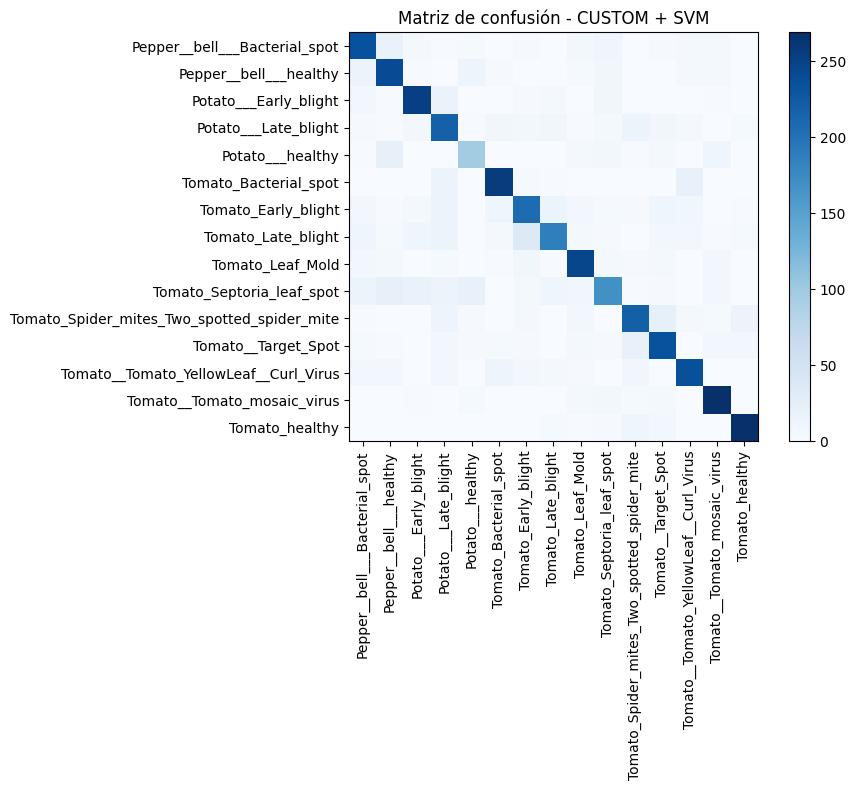

In [ ]:
# ============================================================
# 25. MATRIZ DE CONFUSIÓN Y MÉTRICAS POR CLASE DEL MEJOR MODELO
# ============================================================
best_model_name = df_results.iloc[0]["Modelo"]
print("Mejor modelo:", best_model_name)
mapping = {
    "LBP + kNN": res_lbp_knn,
    "LBP + SVM": res_lbp_svm,
    "LBP + RF": res_lbp_rf,
    "HOG + kNN": res_hog_knn,
    "HOG + SVM": res_hog_svm,
    "HOG + RF": res_hog_rf,
    "CUSTOM + kNN": res_custom_knn,
    "CUSTOM + SVM": res_custom_svm,
    "CUSTOM + RF": res_custom_rf,
    "BOW + kNN": res_bow_knn,
    "BOW + SVM": res_bow_svm,
    "BOW + RF": res_bow_rf,
    "LBP+HOG + SVM": res_lbp_hog_svm,
    "HOG+CUSTOM + SVM": res_hog_custom_svm,
    "LBP+HOG+CUSTOM + SVM": res_lbp_hog_custom_svm,
}
best_res = mapping[best_model_name]

# Mostrar reporte por clase (Accuracy, F1-Score, Precision, Recall)
print("\n=== REPORTE POR CLASE (F1-Score y Accuracy) ===")
report_df = pd.DataFrame(best_res["report"]).transpose()
display(report_df)

# Dibujar Matriz de Confusión
cm = best_res["confusion_matrix"]
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title(f"Matriz de Confusión - {best_model_name}")
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=90)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 26. CONCLUSIONES
# ============================================================
print("1. Se implementó el pipeline completo en el orden solicitado por el enunciado.")
print("2. Se comparó la segmentación antes y después de morfología.")
print("3. Se analizaron bordes y esquinas sobre hojas segmentadas.")
print("4. Se extrajeron LBP, HOG, BOW y un descriptor propio.")
print("5. Se evaluó clasificación con kNN, SVM y Random Forest usando k-fold.")
print("6. Se comparó el desempeño individual y combinado de los descriptores.")

1. Se implementó el pipeline completo en el orden solicitado por el enunciado.
2. Se comparó la segmentación antes y después de morfología.
3. Se analizaron bordes y esquinas sobre hojas segmentadas.
4. Se extrajeron LBP, HOG, BOW y un descriptor propio.
5. Se evaluó clasificación con kNN, SVM y Random Forest usando k-fold.
6. Se comparó el desempeño individual y combinado de los descriptores.
